In [30]:
""" Chapter 03: Classification """

# As we know, the most common supervised learning tasks are regression (Predicting values) and Classification (Predicting class)

""" 1. MNIST """
# The "MNIST" dataset is a set of 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau
# "Hello, World!" of the Machine Learning

# 3.1: Fetches the MNIST dataset from OpenML.org
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

# fetch_openml() to download real-life datasets,
# load_openml() to load small toy datasets bundled with Scikit-Learn,
# make_openml() to generate fake datasets, and useful for tests.

# The datasets usually returns as an (X, y) tuple containing the input data and the targets both as NumPy arrays.

In [31]:
# DESCR = A description of the dataset
# data = The input data, usually as a 2D NumPy array
# target = The labels usually as a 1D NumPY array

# The MNIST dataset contains images, and DataFrame aren't ideal for that, so it's preferable to set as_frame=False to get the data as NumPy array

X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [32]:
X.shape

(70000, 784)

In [33]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [34]:
y.shape

(70000,)

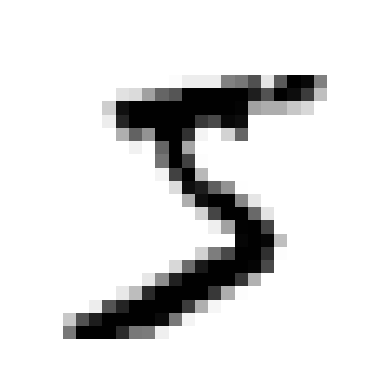

In [35]:
# There are 70,000 images, and each image has 784 features.
# 28 X 28 pixels and each feature simply represents one pixel's intensity. from 0 white to 255 black
# We use cmap="binary" to get a grayscale color map where 0 is white and 255 is black.

import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [36]:
# You noticed it's looks like a 5? indeed!
y[0]

'5'

In [37]:
# You should always create a test set and set it aside before inspecting the data closely.
# fetch_openml() is actually already split into a training set (the first 60,000 images) and a test set (the last 10,000 images)

X_train, X_test, y_train, y_test = X[:60000], X[60000], y[:60000], y[60000:]

# Some learning algorithms are sensitive to the order of the training instances, and they perform poorly if they get many similar instances in a row
# Shuffling the dataset ensures that this won't happen.

In [38]:
""" 2. Training a Binary Classifier """

# The number 5 or The "5-detector" will be an example of a binary classifier
# Capable of distinguishing betwenn just 2 classes, 5 and non-5
# Create the target vectors for this classification task:

y_train_5 = (y_train == '5') # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [39]:
# Start with a "stochastic gradient descent (SGD or stochastic GD)" classifier, using Scikit-Learn's SGDClassifier class
# SGD deals with training instances independentlly , one at a time, which also makes SGD well suited for an online learning

# 3.2: Create an SGDClassifier and train it on the whole training set:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# use it to detect image of the number 5:
sgd_clf.predict([some_digit])

array([ True])

In [40]:
""" 3. Performance Measures """

""" Measuring Accuracy Using Cross-Validation """

# The "cross_val_score()" function to evaluate our SGDClassifier model, using k-fold cross-validation with 3 fold,
# k-fold cross-validation means splitting the training set into k folds (in this case, 3),
# then training the model k times holding out a different fold each time for evaluation

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [41]:
# 95% looks decents
# check out a dummy classifier that just classfiers every single image in the most frequent class, which is this case is the nagative class
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # Prints False: no 5s detected

False


In [42]:
# Find out the model accuracy:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [43]:
# 90% accuracy
# Only about 10% of the images are 5s, so if you always guess that an image is not a 5, you will be right about 90% of the time!

# That's why "accuracy" not preferred performance meansure for classifier.
# Especially, when you dealing with skewed datasets

In [44]:
# Implementing Cross-Validation
# you can implement cross-validation yourself
# Using Scikit-Learn's cross_val_score()
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is not ready to shuffled.

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

    # The StratifiedKFold class performs stratified sampling and produce folds that contain a representative ratio of each class.
    # trains that clone on the training folds, and makes prediction on the test folds,
    # counts the number of correct predictions and outputs the ratio of correct prediction.

0.95035
0.96035
0.9604


In [45]:
""" 4. Confusion Matrices """

# To count the number of times instances of class A are classified as class B, for all A/B pairs.
# Ex. If you wanna know the number of times the classifier confused images of 8s with 0s.
# You would look at row #8 column #0 of the confusion matrix.

# To compute the confusion matrix, you first need to have a set of prediction so that they can be compared to the actual targets.
# or use the cross_val_predict()

from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [46]:
# cross_val_predict() performs k-fold cross-validation but instead of returning the evaluation scores,
# it returns the prediction made on each test fold.
# you get a out-of-sample prediction for each instance in the training set

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [47]:
# Each row in a confusion matrix represents an 'actual class', while each column represents a 'predicted class'
# A perfect classifier would only have true positives and true negatives so its confusion matrix would have non-zero values only on its main diagonal

y_train_perfect_predictions = y_train_5 # Pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [48]:
# The confusion matrix gives you a lot of information but sometimes you may prefer a more concise metric.

# Precision = TP / TP + FP
# TP is the number of true postitives, and FP is the number of false positives

# Recall = TP / TP + FN 
# sensitivity or the true positive rate (TPR)
# The ratio of positive instances athat are correctly detected by the classifier
# FN = the false negatives

In [49]:
""" 5. Precision and Recall """
# You can use it on Scikit-Learn

from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred) # == 3530 / (687 + 3530)

0.8370879772350012

In [50]:
recall_score(y_train_5, y_train_pred) # == 3530 / (1891 + 3530)

0.6511713705958311

In [51]:
# It is often conveninet to combine precision and recall into a single metric called the f1 score,
# especially when you need a single metric to compare 2 classifiers.
# The F1 score is the harmonic mean of precision and recall

# The harmonic mean gives much more weight to low values.

# F1 Score = (2 / (1 / Precision) + (1 / Recall)) = (2 * Precision * Recall / Precision + Recall) = (TP / TP + (FN + FP / 2))

from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [52]:
# The F1 score favors classifiers that have similar precision and recall
# In some contexts you mostly care about precision and in other contexts you really care about recall.
# Increasing precision reduces recall and vice versa. This is called the "precision/recall trade-off"

In [53]:
""" The Precision/Recall Trade Off """

# For each instance, it computes a score based on a decision function.
# If that score is greater than a threshold, it assigns the instance to positive class; otherwise it assigns it to the negative class
# The higher the threshold, the lower the recall, but (in general) the higher the precision.

# Scikit-Learn does not let you set the threshold directly, but it does give you access to the decision scores that it uses to make prediction.
# decision_function() = returns a score for each instance and the use any threshold you want to make predictions

y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [54]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [55]:
# The SGDClassifer uses a threshold equal to 0, so the preceding code returns the same result as the predict() method
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [57]:
# This is confirms that raising the threshold decrease recall.

# Use the cross_val_predict() function to get the scores of all instances in the training set but this time
# specify that you want to return decision scores instead of prediction:

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [58]:
# Use the precision_recall_curve() function to compute precision and recall for all possible thresholds.
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [ ]:
# Use Matplotlib to plot precision and recall as functions of the threshold value
